# Salary prediction problem


## Problem satatement
- Predict an individual’s annual salary based on professional attributes.

In [56]:
%pip install scikit-learn seaborn xgboost streamlit --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\oto23\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor



In [58]:
df = pd.read_csv('salary_dataset.csv')

In [59]:
#view the first five rows
df.head()

,EmployeeID,Age,YearsExperience,YearsAtCompany,Department,EducationLevel,PerformanceRating,MonthlyHoursWorked,MonthlySalary
0,1,44,26,13.00,Sales,Bachelor,4.00,160.00,167000.00
1,2,38,18,0.00,Engineering,Bachelor,4.00,163.00,174000.00
2,3,46,24,3.00,Sales,Master,5.00,159.00,223000.00
3,4,55,31,12.00,Engineering,High School,1.00,148.00,125000.00
4,5,37,17,11.00,HR,Bachelor,2.00,172.00,115000.00


In [60]:
#check the dimensions of the dataset
df.shape

(1000, 9)

- The dataset has 1000 observations and 9 columns

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   EmployeeID          1000 non-null   int64  
 1   Age                 1000 non-null   int64  
 2   YearsExperience     1000 non-null   int64  
 3   YearsAtCompany      946 non-null    float64
 4   Department          1000 non-null   str    
 5   EducationLevel      1000 non-null   str    
 6   PerformanceRating   949 non-null    float64
 7   MonthlyHoursWorked  948 non-null    float64
 8   MonthlySalary       1000 non-null   float64
dtypes: float64(4), int64(3), str(2)
memory usage: 70.4 KB


- There are missing values in YearsAtCompany, PerformaceRating, and MonthlyHoursWorked column. Missing values must be handled appropriately

- All column seems to have the right data type

- There are two columns with str datatype, while others are numerical


In [62]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
EmployeeID,1000.00,500.50,288.82,1.00,250.75,500.50,750.25,1000.00
Age,1000.00,39.76,9.49,22.00,33.00,40.00,46.00,65.00
YearsExperience,1000.00,17.43,9.65,0.00,11.00,17.00,24.00,47.00
YearsAtCompany,946.00,3.75,4.05,0.00,1.00,2.00,5.00,22.00
PerformanceRating,949.00,3.25,0.98,1.00,3.00,3.00,4.00,5.00
MonthlyHoursWorked,948.00,169.61,14.54,140.00,160.00,170.00,180.00,216.00
MonthlySalary,1000.00,152093.00,42559.88,70000.00,121000.00,147000.00,176000.00,317000.00


- The descriptive analysis confirmed the presence of missing values.
- Age, YearsExperience, PerformanceRating, MonthlyHoursWorked are moderately normally distributed, while YearsAtCompany, MonthlySalary are likely right skwed

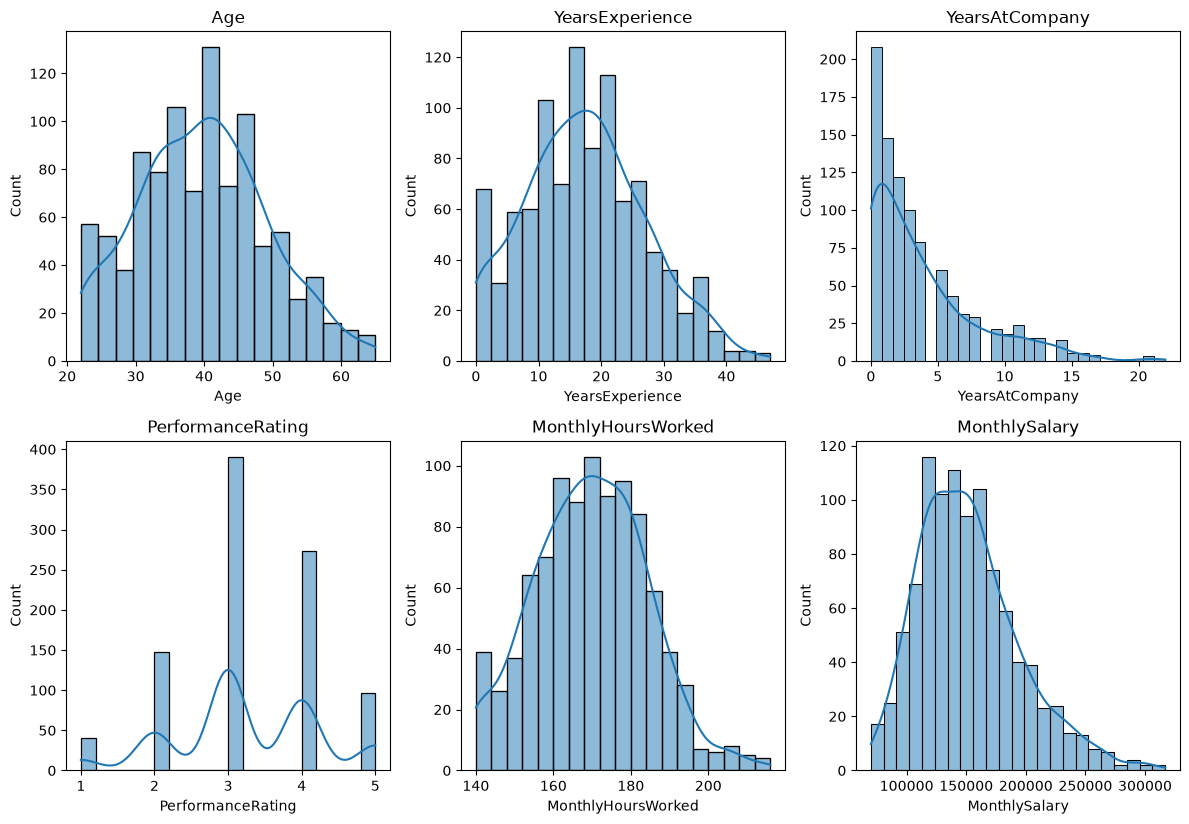

In [63]:

# visualising the distribution of numerical columns
import math

# selecting numerical cols alone, and excluding the EmployeeID
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if col != 'EmployeeID']

n = len(num_cols)
rows = math.ceil(n / 2) #for subplot

plt.figure(figsize=(12, rows * 4))
for i, col in enumerate(num_cols, 1):  
    plt.subplot(rows, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [64]:
df.isnull().sum()

EmployeeID             0
Age                    0
YearsExperience        0
YearsAtCompany        54
Department             0
EducationLevel         0
PerformanceRating     51
MonthlyHoursWorked    52
MonthlySalary          0
dtype: int64

In [65]:
#Check the sunm of null values
missing = df[['YearsAtCompany', 'PerformanceRating', 'MonthlyHoursWorked']].isnull().sum().sum()
missing_per = (missing/len(df) * 100)
print(f'The percentage of missing value is: {missing_per}%')


The percentage of missing value is: 15.7%


- Investigating the columns with missing values

In [66]:
df.loc[df['YearsAtCompany'].isnull(), ['Department','EducationLevel', 'MonthlySalary', 'PerformanceRating', 'MonthlyHoursWorked']].head(5)

,Department,EducationLevel,MonthlySalary,PerformanceRating,MonthlyHoursWorked
74,Sales,Bachelor,96000.00,2.00,146.00
81,Sales,Master,188000.00,3.00,NaN
89,HR,High School,113000.00,4.00,178.00
93,Engineering,PhD,234000.00,3.00,181.00
116,Finance,Bachelor,194000.00,4.00,155.00


In [67]:
df.loc[df['PerformanceRating'].isnull(), ['YearsAtCompany', 'EducationLevel', 'MonthlySalary', 'MonthlyHoursWorked']].head(5)

,YearsAtCompany,EducationLevel,MonthlySalary,MonthlyHoursWorked
13,0.00,Master,130000.00,155.00
22,11.00,Bachelor,121000.00,168.00
36,2.00,Bachelor,139000.00,190.00
37,0.00,Bachelor,147000.00,153.00
42,4.00,PhD,163000.00,175.00


In [68]:
df.loc[df['MonthlyHoursWorked'].isnull(), ['YearsAtCompany', 'EducationLevel', 'MonthlySalary', 'PerformanceRating']].head(5)

,YearsAtCompany,EducationLevel,MonthlySalary,PerformanceRating
14,4.00,High School,129000.00,4.00
26,4.00,Master,188000.00,4.00
46,1.00,Bachelor,151000.00,3.00
52,1.00,High School,113000.00,2.00
81,NaN,Master,188000.00,3.00


- From the above, the columns with null value contains some valuable informations from other columns, deleting all means we are going to about 15% of the datasets. 

- We could better fill all with the median

In [69]:
#Filling all missing values with median
df['YearsAtCompany'] = df['YearsAtCompany'].fillna(df.YearsAtCompany.median())
df['PerformanceRating']=df['PerformanceRating'].fillna(df.PerformanceRating.median())

#filling the monthlyhoursworked based on department
df['MonthlyHoursWorked'] = df.groupby('Department')['MonthlyHoursWorked'] \
                              .transform(lambda x: x.fillna(x.median()))


In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   EmployeeID          1000 non-null   int64  
 1   Age                 1000 non-null   int64  
 2   YearsExperience     1000 non-null   int64  
 3   YearsAtCompany      1000 non-null   float64
 4   Department          1000 non-null   str    
 5   EducationLevel      1000 non-null   str    
 6   PerformanceRating   1000 non-null   float64
 7   MonthlyHoursWorked  1000 non-null   float64
 8   MonthlySalary       1000 non-null   float64
dtypes: float64(4), int64(3), str(2)
memory usage: 70.4 KB


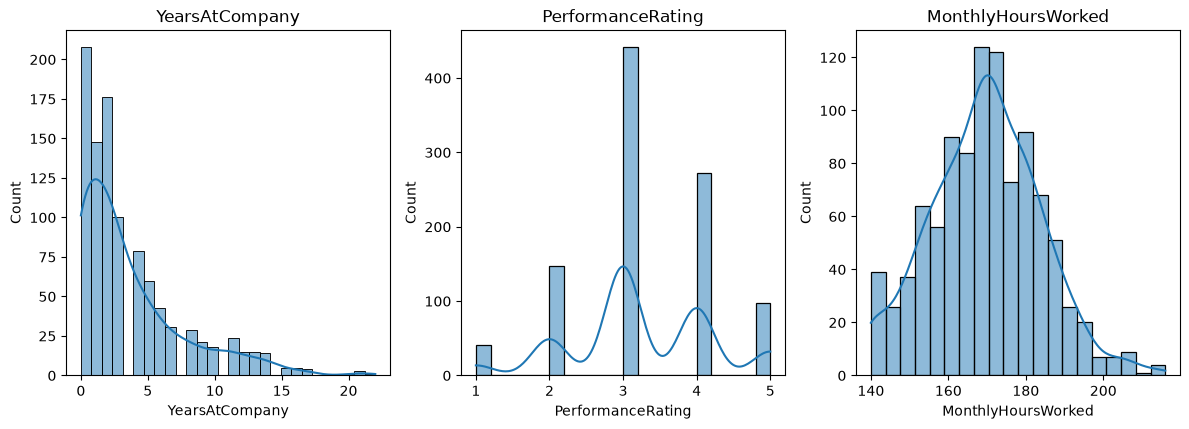

In [71]:
#Visualise distribution after filling
import math

# selecting numerical cols alone, and excluding the EmployeeID
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if col in ['YearsAtCompany', 'PerformanceRating', 'MonthlyHoursWorked']]

n = len(num_cols)
rows = math.ceil(n / 2) #for subplot

plt.figure(figsize=(12, rows * 4))
for i, col in enumerate(num_cols, 1):  
    plt.subplot(rows, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

- The distributions are similar to the ones before filling the missing values

## Relationship between categorical variables and salary

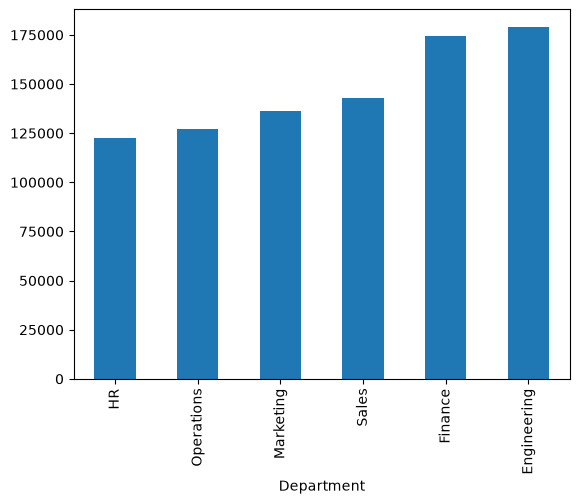

In [72]:
# Deparment and salary
df.groupby('Department')['MonthlySalary'].mean().sort_values().plot(kind='bar')
plt.show()

- Engineering and finance department receives the highest salary
- HR, and operations department have similar and the lowest salary range followed by marketing and sales department respectively.


In [73]:
df.columns

Index(['EmployeeID', 'Age', 'YearsExperience', 'YearsAtCompany', 'Department',
       'EducationLevel', 'PerformanceRating', 'MonthlyHoursWorked',
       'MonthlySalary'],
      dtype='str')

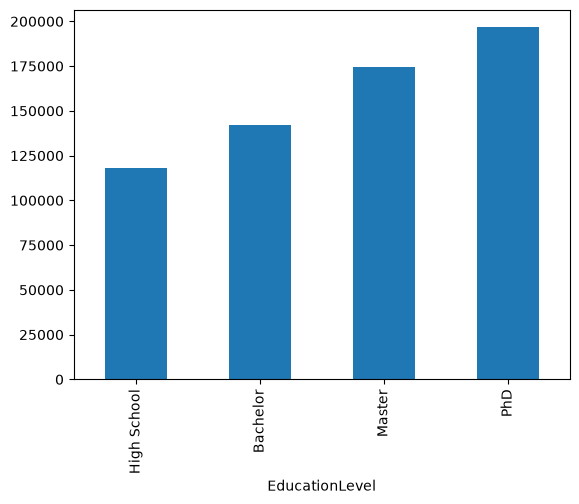

In [74]:
# Education level vs salary
df.groupby('EducationLevel')['MonthlySalary'].mean().sort_values().plot(kind = 'bar')
plt.show()


- This is intuitive, as education level has an effect on salary range. Salary range increases with educational level.

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   EmployeeID          1000 non-null   int64  
 1   Age                 1000 non-null   int64  
 2   YearsExperience     1000 non-null   int64  
 3   YearsAtCompany      1000 non-null   float64
 4   Department          1000 non-null   str    
 5   EducationLevel      1000 non-null   str    
 6   PerformanceRating   1000 non-null   float64
 7   MonthlyHoursWorked  1000 non-null   float64
 8   MonthlySalary       1000 non-null   float64
dtypes: float64(4), int64(3), str(2)
memory usage: 70.4 KB


In [76]:
df.loc[df['MonthlySalary'].idxmax()]

EmployeeID                    335
Age                            49
YearsExperience                27
YearsAtCompany               6.00
Department            Engineering
EducationLevel                PhD
PerformanceRating            4.00
MonthlyHoursWorked         180.00
MonthlySalary           317000.00
Name: 334, dtype: object

The above justifies the max value of salary, as this is from the engineering department with a PhD degree. This means the extreme values in the Salary column is valid.

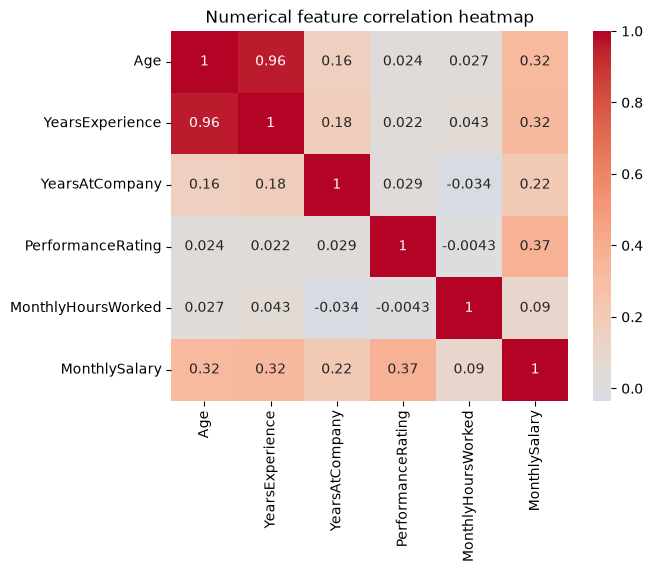

In [77]:
# Investigating the correlation of other numerical columns with salary
num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = [col for col in num_cols if col != 'EmployeeID']

sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', center = 0)
plt.title('Numerical feature correlation heatmap')
plt.show()

- All useful numerical columns except MonthlyHoursWorked are moderately postively correlated with MonthlySalary.

- Age and YearsExperience are highly positively correlated, this is normal becuase Age is the addition of YearsExperience and Starting age. However, this can lead to multicollinearity distorting the model, so Age column will be dropped as it is less relevant compare to YearsExperience for our model

## Data preparation for modelling

#### Using preprocessing pipeline for scaling and categorical encoding

#### Feature selection

In [78]:
#Feature selection
X = df.drop(columns=['MonthlySalary', 'Age', 'EmployeeID'])
y=df['MonthlySalary']

#y = np.log(df['MonthlySalary'])


### Preprocessing pipelines

In [79]:
#identify column types
#num_features = num_cols
#cat_features = [col for col in df.columns if (col not in num_cols) & (col != 'EmployeeID')]

num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['str']).columns

#preprocessing pipeline
num_transformer = Pipeline(steps=[('scaler', StandardScaler())])

cat_transformer = Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[('num', num_transformer, num_features),
                                               ('cat', cat_transformer, cat_features)])




### Train-test data split

In [80]:
#Spliting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=234)
print(f'Size of X_train is: {len(X_train)}, and X_test is {len(X_test)}')
print(f'Size of y_train is: {len(y_train)}, and y_test is {len(y_test)}')

Size of X_train is: 800, and X_test is 200
Size of y_train is: 800, and y_test is 200


### Cross validation and model comparison

In [81]:
# Model definition
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree' : DecisionTreeRegressor(random_state=234),
    'Random Forest' : RandomForestRegressor(random_state=234),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0)   
}

In [82]:
#setting up cross validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=234)
scoring = {
    'MAE':'neg_mean_absolute_error',
    'R2': 'r2'
    }

In [83]:
# cross validation comparison
results = []
for name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor),
                         ('model', model)
                         ])
    
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv =5,
        scoring= scoring)
    results.append({
        'Model': name,
        'MAE': -scores['test_MAE'].mean(),
        'R2': scores['test_R2'].mean(),
        'XGBoost': XGBRegressor(random_state=42, verbosity=0)  
    })
    
    #display results
results_df = pd.DataFrame(results).sort_values(by='MAE').reindex()
print(results_df)

               Model      MAE   R2  \
3            XGBoost 10168.03 0.89   
2      Random Forest 10553.12 0.88   
0  Linear Regression 11118.31 0.88   
1      Decision Tree 14595.00 0.79   

                                             XGBoost  
3  XGBRegressor(base_score=None, booster=None, ca...  
2  XGBRegressor(base_score=None, booster=None, ca...  
0  XGBRegressor(base_score=None, booster=None, ca...  
1  XGBRegressor(base_score=None, booster=None, ca...  


In [84]:
#Check best model
best_model_name = results_df.iloc[0]['Model']
print(f"\nBest Model: {best_model_name}")

best_model = models[best_model_name]


Best Model: XGBoost


In [85]:
#Logging y data to reduce the effect of extreme values
from sklearn.compose import TransformedTargetRegressor
import numpy as np

#build pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model)
])

# wrapping pipeline with y transformation
final_model = TransformedTargetRegressor(
    regressor=pipeline,
    func=np.log,
    inverse_func=np.exp
)

### Hyperparameter tuning of the best model (XGboost)


In [86]:
from sklearn.model_selection import GridSearchCV



param_grid = {
    'regressor__model__n_estimators': [100, 200],   
    'regressor__model__max_depth': [3, 5, 7],
    'regressor__model__learning_rate': [0.01, 0.1]

}

grid = GridSearchCV(
    final_model,
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best params:", grid.best_params_)

Best params: {'regressor__model__learning_rate': 0.1, 'regressor__model__max_depth': 3, 'regressor__model__n_estimators': 200}


In [87]:
best_model #display the pipeline of the trained model

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.","Pipeline(step...=None, ...))])"
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'exp'>
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['YearsExperience','YearsAtCompany','Department','EducationLevel', 'PerformanceRating','MonthlyHoursWorked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,6
regressor_ regressor_: objectFitted regressor.,Pipeline,"Pipeline(step...=None, ...))])"
transformer_ transformer_: objectTransformer used in :meth:`fit` and :meth:`predict`.,FunctionTransformer,FunctionTrans...validate=True)
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"


### Using the model to predict the test data

In [88]:
y_pred = best_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 8040.408671875
MSE: 121560373.80131653
R2: 0.9270298931446435


- The model's score generally improved after hyperparameter tuning


### Visualisation of the residual


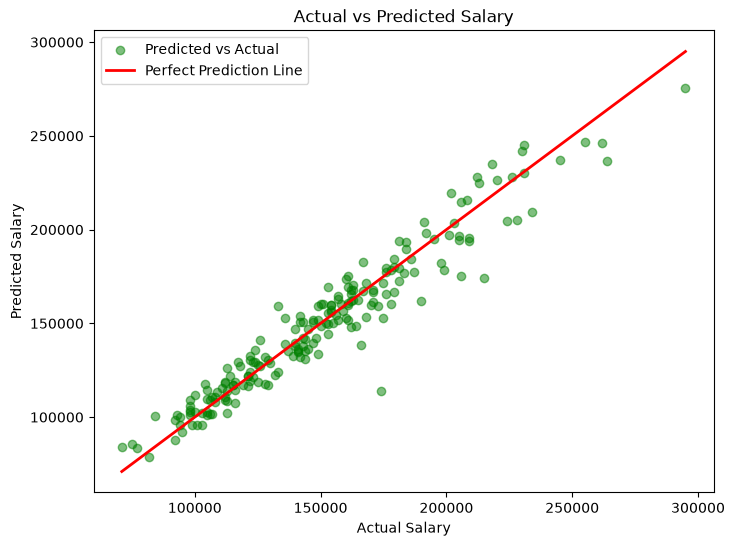

In [89]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.legend()
plt.show()

The predicted versus actual plot shows a strong alignment between predicted and true salary values, with most observations closely following the ideal diagonal line. This indicates that the model captures the underlying relationships effectively, with minimal bias and high predictive accuracy. Slight deviations at higher salary levels suggest some underestimation of extreme values, which is common in regression models

- Feature importance


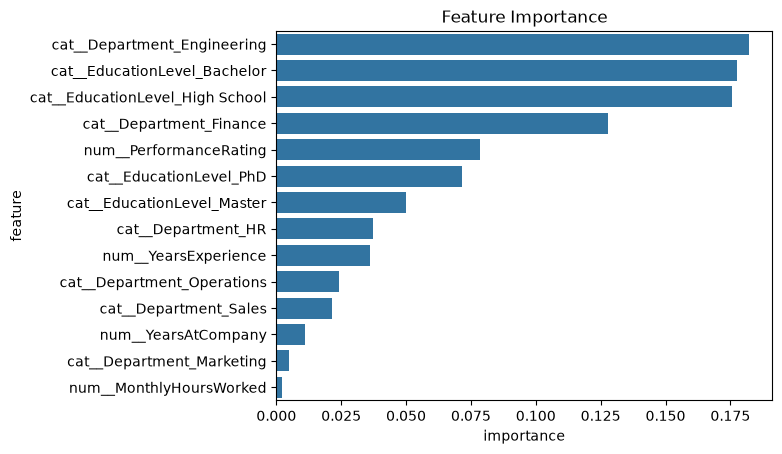

In [90]:

# Get pipeline inside the wrapper
pipeline = best_model.regressor_


# Get model
model = pipeline.named_steps['model']


# Get feature names AFTER preprocessing
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get importances

importances = model.feature_importances_

# Create dataframe
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort
feat_imp = feat_imp.sort_values(by='importance', ascending=False)

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=feat_imp, x='importance', y='feature')
plt.title("Feature Importance")
plt.show()


Feature importance analysis indicates that department and education level are the strongest predictors of salary, followed by performance rating and years of experience. This suggests that role type and qualifications play a dominant role in determining salary, while variables such as tenure and working hours contribute less significantly.

Note: Although, the model says Education_Bachelor > Education_Master > Education_PhD. It should be noted that, importance is directly predictor of salary level but how useful the feature is for splitting

#### Comparing the the actual vs predicted salary

In [91]:
df_result = pd.DataFrame(
    {
        'Actual Salary' : y_test,
        'Predicted Salary' : y_pred
        }
    )
df_result.head()

,Actual Salary,Predicted Salary
809,198000.00,182384.53
891,152000.00,150321.45
328,153000.00,144335.02
297,154000.00,159673.67
319,122000.00,132618.38


In [92]:
#print the min and mx value of both actual and predicted salary
min_act = df_result['Actual Salary'].min()
max_act = df_result['Actual Salary'].max()
min_pred = df_result['Predicted Salary'].min()
max_pred = df_result['Predicted Salary'].max()
print(f'Minimum actual salary: {min_act}')
print(f'Maximum actual salary: {max_act}')
print(f'Minimum predicted salary: {min_pred}')
print(f'Maxium predicted salary: {max_pred}')

Minimum actual salary: 71000.0
Maximum actual salary: 295000.0
Minimum predicted salary: 78768.3984375
Maxium predicted salary: 275404.53125


In [93]:
# difference between actual and predicted
residual = df_result['Actual Salary'] - df_result['Predicted Salary']
df_result['Residual'] = residual
df_result['|Residual|'] = abs(residual)
df_result.head()


,Actual Salary,Predicted Salary,Residual,|Residual|
809,198000.00,182384.53,15615.47,15615.47
891,152000.00,150321.45,1678.55,1678.55
328,153000.00,144335.02,8664.98,8664.98
297,154000.00,159673.67,-5673.67,5673.67
319,122000.00,132618.38,-10618.38,10618.38


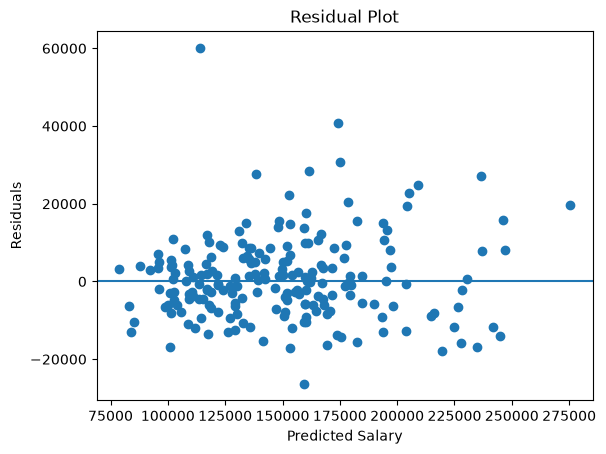

In [94]:
#visualisiing the residual against the predicted
plt.scatter(y_pred, residual)
plt.axhline(y=0)
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

The residual plot indicates that errors are approximately centered around zero, suggesting that the model is unbiased. However, the increasing spread of residuals at higher predicted salary levels likely suggest the model performs less consistently for higher salary values. Additionally, the presence of a few large residuals likely suggests potential outliers which is an area where the model could be improved.

## Model evaluation

In [95]:
# Calculate mean absolute error
MAE = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {MAE:.3f}')

# Calculate mean square error
MSE = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {MSE:.3f}')

#calculate the RMSE manually
RMSE = np.sqrt(MSE)
print(f'Root mean squared error: {RMSE:.3f}')

#calculate the R2
R2 = r2_score(y_test, y_pred)
print(f'R2: {R2:.3f} ({(R2 * 100):.2f}%)')

Mean Absolute Error: 8040.409
Mean Squared Error: 121560373.801
Root mean squared error: 11025.442
R2: 0.927 (92.70%)


The model evaluation after hyperparameter tuning gives R2 of about 93%, and a root mean squared error of approximately 11,025, indicating that predictions deviate from actual salaries by this amount on average. This is reasonable as the Minimum actual salary is 71000.0 and Maximum actual salary: 295000.0

### Evaluating the min and max salary range

In [96]:
#calc max and min price range
df_result['Max_Salary_Range'] = df_result['Predicted Salary'] + RMSE
df_result['Min_Salary_Range'] = df_result['Predicted Salary'] - RMSE

#compare the actual, predicted and min, max range
pd.options.display.float_format = '{:.2f}'.format
df_result[['Predicted Salary', 'Max_Salary_Range', 'Min_Salary_Range', 'Actual Salary']].head()


,Predicted Salary,Max_Salary_Range,Min_Salary_Range,Actual Salary
809,182384.53,193409.97,171359.09,198000.00
891,150321.45,161346.89,139296.02,152000.00
328,144335.02,155360.45,133309.58,153000.00
297,159673.67,170699.11,148648.23,154000.00
319,132618.38,143643.81,121592.93,122000.00


In [97]:
# in range prediction
df_result['Actual_in_Pred_Range'] = np.where(
    (df_result['Predicted Salary'] >= df_result['Min_Salary_Range']) &
    (df_result['Predicted Salary'] <= df_result['Max_Salary_Range']),
    'Yes',
    'No'
)
    
df_result.head(10)

,Actual Salary,Predicted Salary,Residual,|Residual|,Max_Salary_Range,Min_Salary_Range,Actual_in_Pred_Range
809,198000.00,182384.53,15615.47,15615.47,193409.97,171359.09,Yes
891,152000.00,150321.45,1678.55,1678.55,161346.89,139296.02,Yes
328,153000.00,144335.02,8664.98,8664.98,155360.45,133309.58,Yes
297,154000.00,159673.67,-5673.67,5673.67,170699.11,148648.23,Yes
319,122000.00,132618.38,-10618.38,10618.38,143643.81,121592.93,Yes
478,123000.00,121424.44,1575.56,1575.56,132449.88,110398.99,Yes
148,262000.00,246095.05,15904.95,15904.95,257120.48,235069.61,Yes
322,100000.00,111984.50,-11984.50,11984.50,123009.95,100959.05,Yes
620,107000.00,101577.36,5422.64,5422.64,112602.80,90551.91,Yes
890,140000.00,147081.44,-7081.44,7081.44,158106.88,136056.00,Yes


In [98]:
# Check how many actual falls within the predicted range

print(f'Avg. Coverage: {(df_result['Actual_in_Pred_Range'] == 'Yes').mean() * 100:.2f}%')

# how many were captured
print(f'The model\'s predicted range is {(df_result['Actual_in_Pred_Range'] == 'Yes').sum()}\
 out of {len(y_test)}\
      ')

Avg. Coverage: 100.00%
The model's predicted range is 200 out of 200      


The model’s predicted range fully covers all observed salary values, however, this measure must be interpreted alongside error-based metrics such as MAE, RMSE, and R2.

## Saving the model

In [99]:
import joblib


# save the best model
joblib.dump(best_model, 'salary_trained_model_Xgboost.pkl')
print(f'Model saved as salary_trained_model_Xgboost.pkl')

Model saved as salary_trained_model_Xgboost.pkl


In [100]:
model = joblib.load('salary_trained_model_Xgboost.pkl')

In [46]:
#predicting on random data
new_data = pd.DataFrame({
    'Age': [20],
    'YearsExperience': [10],
    'YearsAtCompany': [90],
    'Department': ['Engineering'],
    'EducationLevel': ['Phd'],
    'PerformanceRating': [10],
    'MonthlyHoursWorked': [40]
})

prediction = model.predict(new_data)
print(prediction)

[250659.9]


# Conclusions
- The model generally informed us that Salary is a function of department (role type), education, performance, and experience.

- The model was implemented using a pipeline, which ensures a cleaner and more consistent workflow by integrating preprocessing and modelling steps. Additionally, cross-validation was applied to achieve more reliable performance evaluation across multiple data splits.

- The target variable was also log-transformed to reduce the influence of extreme values and improve model stability, particularly for higher salary ranges

- Four different models were compared, XGboost seems to be the best (the pipeline were kept, even tho XGboost will still perform well without scaling)

- Hyperparamer tunning of XGboost enhanced its performace.

- The model demonstrates good generalisation on the test data, despite the relatively small dataset size, indicating that it captures the underlying patterns effectively.

    